In [2]:
pip install opensignalsreader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.2 MB/s eta 0:00:00


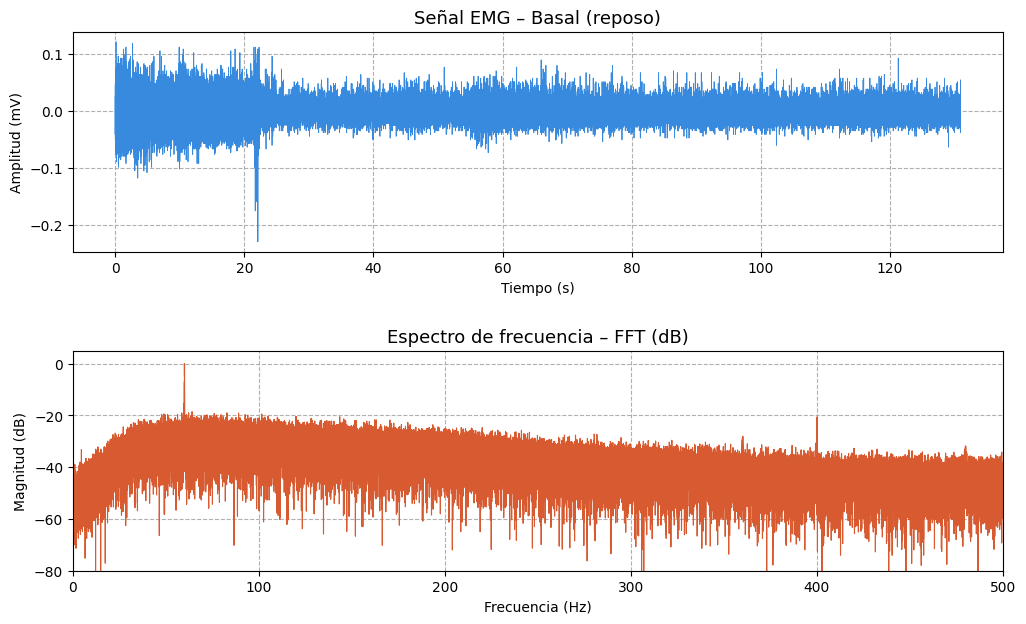

In [14]:
from opensignalsreader import OpenSignalsReader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Lectura ─────────────────────────────────────────
acq = OpenSignalsReader('basal.txt')
fs = acq.sampling_rate # lee la fs real de la señal

# Obtener la señal EMG
signal = acq.signal()['EMG'].astype(float)

# ── Pre-procesamiento ────────────────────────────────
signal -= signal.mean() # eliminar componente DC
t = np.arange(len(signal)) / fs # definir el tiempo

# ── FFT ─────────────────────────────────────────────
N = len(signal)
window = np.hanning(N) # ventana de Hanning
fft_mag = np.abs(np.fft.rfft(signal * window)) # magnitud de las frecuencias positivas
freqs = np.fft.rfftfreq(N, d=1/fs) # frecuencias encontradas
# Convertir a dB (normalizado al máximo)
fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)

# Recortar a 0-500 Hz (rango relevante de EMG)
mask = freqs <= 500

# ── Figura ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, hspace=0.45)

# — Señal temporal —
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, signal, color='#378ADD', lw=0.6)
ax1.set_title('Señal EMG – Basal (reposo)', fontsize=13)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# — Espectro FFT en dB —
ax2 = fig.add_subplot(gs[1])
ax2.plot(freqs[mask], fft_db[mask], color='#D85A30', lw=0.8)
ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_ylim(-80, 5)
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--')

plt.show()

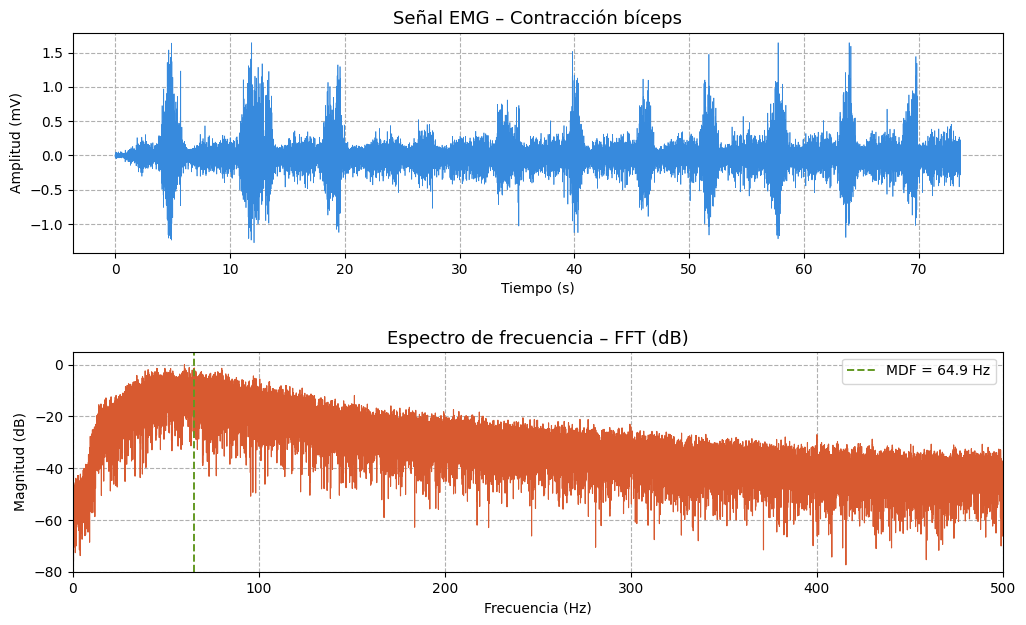

Frecuencia mediana (MDF): 64.9 Hz


In [15]:
# ── Lectura ─────────────────────────────────────────
acq = OpenSignalsReader('contraccion1.txt')
fs = acq.sampling_rate

signal = acq.signal()['EMG'].astype(float)

# ── Pre-procesamiento ────────────────────────────────
signal -= signal.mean()
t = np.arange(len(signal)) / fs

# ── FFT ─────────────────────────────────────────────
N = len(signal)
window = np.hanning(N)
fft_mag = np.abs(np.fft.rfft(signal * window))
freqs = np.fft.rfftfreq(N, d=1/fs)
fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)
mask = freqs <= 500
# ── Frecuencia mediana (MDF) ─────────────────────────
power = fft_mag[mask] ** 2
cumpower = np.cumsum(power)
mdf = freqs[mask][np.searchsorted(cumpower, cumpower[-1] / 2)] #hayamos la frecuencia donde se alcanza la mitad de la potencia total

# ── Figura ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, hspace=0.45)

# — Señal temporal —
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, signal, color='#378ADD', lw=0.5)
ax1.set_title('Señal EMG – Contracción bíceps', fontsize=13)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# — Espectro FFT en dB —
ax2 = fig.add_subplot(gs[1])
ax2.plot(freqs[mask], fft_db[mask], color='#D85A30', lw=0.8)
ax2.axvline(mdf, color='#639922', lw=1.4, linestyle='--', label=f'MDF = {mdf:.1f} Hz')
ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_ylim(-80, 5)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--')

plt.show()
print(f'Frecuencia mediana (MDF): {mdf:.1f} Hz')

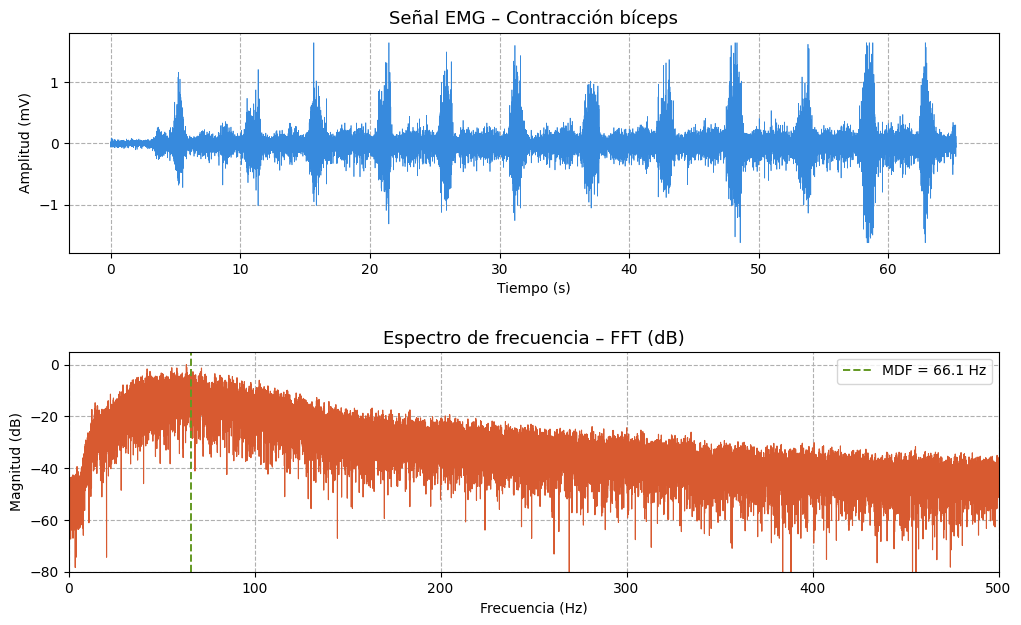

Frecuencia mediana (MDF): 66.1 Hz


In [16]:
# ── Lectura ─────────────────────────────────────────
acq = OpenSignalsReader('contraccion2.txt')
fs = acq.sampling_rate

signal = acq.signal()['EMG'].astype(float)

# ── Pre-procesamiento ────────────────────────────────
signal -= signal.mean()
t = np.arange(len(signal)) / fs

# ── FFT ─────────────────────────────────────────────
N = len(signal)
window = np.hanning(N)
fft_mag = np.abs(np.fft.rfft(signal * window))
freqs = np.fft.rfftfreq(N, d=1/fs)
fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)
mask = freqs <= 500
# ── Frecuencia mediana (MDF) ─────────────────────────
power = fft_mag[mask] ** 2
cumpower = np.cumsum(power)
mdf = freqs[mask][np.searchsorted(cumpower, cumpower[-1] / 2)] #hayamos la frecuencia donde se alcanza la mitad de la potencia total

# ── Figura ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, hspace=0.45)

# — Señal temporal —
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, signal, color='#378ADD', lw=0.5)
ax1.set_title('Señal EMG – Contracción bíceps', fontsize=13)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# — Espectro FFT en dB —
ax2 = fig.add_subplot(gs[1])
ax2.plot(freqs[mask], fft_db[mask], color='#D85A30', lw=0.8)
ax2.axvline(mdf, color='#639922', lw=1.4, linestyle='--', label=f'MDF = {mdf:.1f} Hz')
ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_ylim(-80, 5)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--')

plt.show()
print(f'Frecuencia mediana (MDF): {mdf:.1f} Hz')

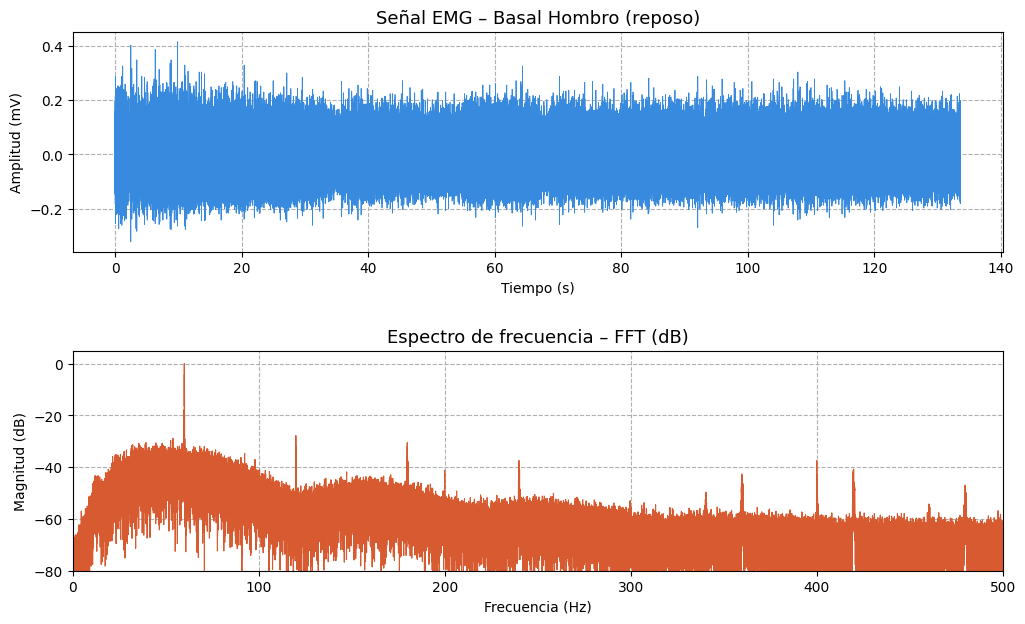

In [17]:
# ── Lectura ─────────────────────────────────────────
acq = OpenSignalsReader('basal2hombro.txt')
fs = acq.sampling_rate # lee la fs real

# Obtener la señal EMG (canal 0 o por nombre)
signal = acq.signal()['EMG'].astype(float) # canal 1; ajusta si es necesario

# ── Pre-procesamiento ────────────────────────────────
signal -= signal.mean() # eliminar componente DC
t = np.arange(len(signal)) / fs

# ── FFT ─────────────────────────────────────────────
N = len(signal)
window = np.hanning(N) # ventana de Hanning
fft_mag = np.abs(np.fft.rfft(signal * window))
freqs = np.fft.rfftfreq(N, d=1/fs)
# Convertir a dB (normalizado al máximo)
fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)

# Recortar a 0-500 Hz (rango relevante de EMG)
mask = freqs <= 500

# ── Figura ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, hspace=0.45)

# — Señal temporal —
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, signal, color='#378ADD', lw=0.6)
ax1.set_title('Señal EMG – Basal Hombro (reposo)', fontsize=13)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# — Espectro FFT en dB —
ax2 = fig.add_subplot(gs[1])
ax2.plot(freqs[mask], fft_db[mask], color='#D85A30', lw=0.8)
ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_ylim(-80, 5)
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--')

plt.show()

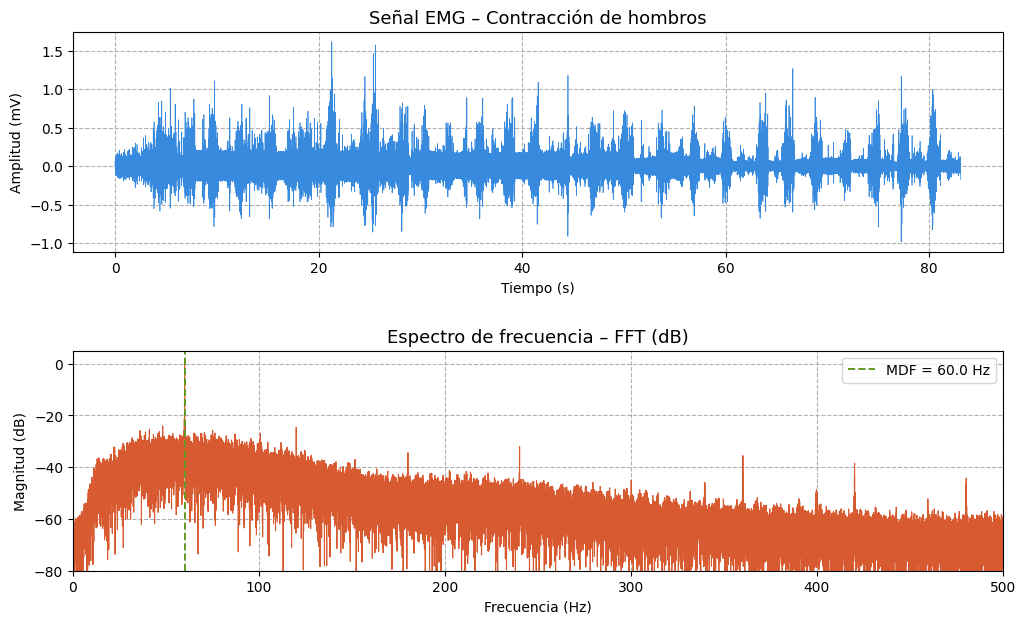

Frecuencia mediana (MDF): 60.0 Hz


In [18]:
# ── Lectura ─────────────────────────────────────────
acq = OpenSignalsReader('contraccion2hombros.txt')
fs = acq.sampling_rate

signal = acq.signal()['EMG'].astype(float)

# ── Pre-procesamiento ────────────────────────────────
signal -= signal.mean()
t = np.arange(len(signal)) / fs

# ── FFT ─────────────────────────────────────────────
N = len(signal)
window = np.hanning(N)
fft_mag = np.abs(np.fft.rfft(signal * window))
freqs = np.fft.rfftfreq(N, d=1/fs)
fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)
mask = freqs <= 500
# ── Frecuencia mediana (MDF) ─────────────────────────
power = fft_mag[mask] ** 2
cumpower = np.cumsum(power)
mdf = freqs[mask][np.searchsorted(cumpower, cumpower[-1] / 2)]

# ── Figura ──────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(2, 1, hspace=0.45)

# — Señal temporal —
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, signal, color='#378ADD', lw=0.5)
ax1.set_title('Señal EMG – Contracción de hombros', fontsize=13)
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

# — Espectro FFT en dB —
ax2 = fig.add_subplot(gs[1])
ax2.plot(freqs[mask], fft_db[mask], color='#D85A30', lw=0.8)
ax2.axvline(mdf, color='#639922', lw=1.4, linestyle='--', label=f'MDF = {mdf:.1f} Hz')
ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_ylim(-80, 5)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--')

plt.show()
print(f'Frecuencia mediana (MDF): {mdf:.1f} Hz')